# Project 6 — Weekly Radar: Cross-Sectional Anomaly Detection and Ranking

This notebook continues **after preprocessing** and uses the cleaned file  
`weekly_region_carrier_tech.csv` as the main input table.

## What this notebook does
1. Loads the cleaned Project 6 table.
2. Re-checks the structure and the inherited preprocessing decisions.
3. Builds analysis tables for:
   - overall **region × week**
   - **region × technology × week**
   - **region × carrier × week**
4. Detects anomalies using a **cross-sectional peer comparison** approach.
5. Adds a **week-over-week change** analysis for regional drift.
6. Answers all Project 6 questions (Q1–Q5).
7. Produces the extra deliverables:
   - carrier report
   - region ranking table
   - mean-vs-median analysis
   - anomaly log

## Why this modeling style fits Project 6
Project 6 has only **3 weekly snapshots**, so the project itself tells us to focus more on
**cross-sectional anomaly detection** and **week-over-week change analysis** than on long-history time-series methods.


## Step 19 — Import the libraries

We continue with the same style as the preprocessing notebook:

- **pandas** for data handling
- **numpy** for numeric work
- **matplotlib** and **seaborn** for plots
- **pathlib** for file paths

We also use a few helper display settings so the notebook stays easy to read.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 200)


## Step 20 — Load the cleaned Project 6 table

If you merge this notebook with the preprocessing notebook later, it can reuse `final_df` directly.
Otherwise, it will load `weekly_region_carrier_tech.csv` from disk.


In [2]:
# Load the cleaned Project 6 table.
# If this notebook is run immediately after the preprocessing notebook in the same kernel,
# it will reuse final_df. Otherwise, it searches for the saved CSV.
candidate_weekly_region_paths = [
    Path("./Processed_Data/weekly_region_carrier_tech.csv"),
    Path("./weekly_region_carrier_tech.csv"),
    Path("/mnt/data/Processed_Data/weekly_region_carrier_tech.csv"),
    Path("/mnt/data/weekly_region_carrier_tech.csv"),
]


def parse_aggregate_date(date_series):
    if pd.api.types.is_datetime64_any_dtype(date_series):
        return pd.to_datetime(date_series, errors="coerce")

    cleaned = date_series.astype(str).str.strip()
    parsed = pd.to_datetime(cleaned, format="%Y-%m-%d", errors="coerce")

    missing_mask = parsed.isna()
    if missing_mask.any():
        parsed.loc[missing_mask] = pd.to_datetime(
            cleaned.loc[missing_mask],
            format="%d/%m/%Y",
            errors="coerce",
        )

    missing_mask = parsed.isna()
    if missing_mask.any():
        parsed.loc[missing_mask] = pd.to_datetime(
            cleaned.loc[missing_mask],
            format="%m/%d/%Y",
            errors="coerce",
        )

    missing_mask = parsed.isna()
    if missing_mask.any():
        parsed.loc[missing_mask] = pd.to_datetime(cleaned.loc[missing_mask], errors="coerce")

    return parsed


if "final_df" in globals():
    analysis_df = final_df.copy()
    print("Using `final_df` from the preprocessing notebook.")
else:
    weekly_region_path = next((path for path in candidate_weekly_region_paths if path.exists()), None)
    if weekly_region_path is None:
        searched_paths = "\n".join(str(path) for path in candidate_weekly_region_paths)
        raise FileNotFoundError(
            "Could not find weekly_region_carrier_tech.csv. Searched these paths:\n" + searched_paths
        )
    analysis_df = pd.read_csv(weekly_region_path)
    print(f"Loaded cleaned file from: {weekly_region_path}")

analysis_df["aggregate_date"] = parse_aggregate_date(analysis_df["aggregate_date"])
analysis_df = analysis_df.dropna(subset=["aggregate_date"]).copy()
analysis_df["week_label"] = analysis_df["aggregate_date"].dt.strftime("%Y-%m-%d")

print("Shape:", analysis_df.shape)
print("Weeks present:", sorted(analysis_df["week_label"].unique().tolist()))

expected_weeks = ["2026-03-01", "2026-03-08", "2026-03-15"]
assert sorted(analysis_df["week_label"].unique().tolist()) == expected_weeks, "Expected exactly the three Project 6 weeks."
assert analysis_df["region"].nunique() == 13, "Expected 13 regions in the cleaned Project 6 table."
assert analysis_df["carrier_name"].nunique() == 3, "Expected 3 carriers in the cleaned Project 6 table."
assert analysis_df["technology_type"].nunique() == 3, "Expected 3 technologies in the cleaned Project 6 table."

analysis_df.head()


Loaded cleaned file from: Processed_Data\weekly_region_carrier_tech.csv
Shape: (343, 19)
Weeks present: ['2026-03-01', '2026-03-08', '2026-03-15']


,aggregate_date,region,carrier_name,technology_type,n_source_rows,n_unique_localities,sample_count_total,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps_approx,median_upload_kbps_approx,median_latency_ms_approx,week_label,mean_minus_median_download,mean_minus_median_upload,mean_minus_median_latency,download_median_gap_pct,latency_median_gap_pct
0,2026-03-01,Alexandria,Operator A,5G,7,1,95,387527.021053,25050.410526,25.989474,323356.042105,14374.905263,25.378947,2026-03-01,64170.978947,10675.505263,0.610526,19.845301,2.405641
1,2026-03-01,Alexandria,Operator A,LTE,54,11,280,83041.117857,11382.528571,37.942857,65839.882143,7866.121429,33.421429,2026-03-01,17201.235714,3516.407143,4.521429,26.125860,13.528532
2,2026-03-01,Alexandria,Operator A,Multi-RAT,54,11,359,153778.941504,14765.715877,35.793872,112277.000000,9743.211699,31.615599,2026-03-01,41501.941504,5022.504178,4.178273,36.963885,13.215859
3,2026-03-01,Alexandria,Operator B,5G,19,3,774,424300.195090,35962.344961,34.996124,376209.908269,24854.611111,33.125323,2026-03-01,48090.286822,11107.733850,1.870801,12.782834,5.647646
4,2026-03-01,Alexandria,Operator B,LTE,351,70,1632,96968.941176,15995.157475,41.698529,81423.069853,12672.598652,37.955270,2026-03-01,15545.871324,3322.558824,3.743260,19.092711,9.862293


## Step 21 — Re-check the structure inherited from preprocessing

We want to confirm that the input table already represents one row per:

**`region × carrier × technology × week`**

We also check whether the preprocessing threshold on `sample_count_total` is still visible in the final file.


In [3]:
print("Columns:")
print(analysis_df.columns.tolist())

print("\nUnique regions:", analysis_df["region"].nunique())
print("Unique carriers:", analysis_df["carrier_name"].nunique())
print("Unique technologies:", analysis_df["technology_type"].nunique())
print("Unique weeks:", analysis_df["aggregate_date"].nunique())

print("\nWeeks present:")
print(sorted(analysis_df["week_label"].unique().tolist()))

print("\n`sample_count_total` summary:")
print(analysis_df["sample_count_total"].describe())


Columns:
['aggregate_date', 'region', 'carrier_name', 'technology_type', 'n_source_rows', 'n_unique_localities', 'sample_count_total', 'mean_download_kbps', 'mean_upload_kbps', 'mean_latency_ms', 'median_download_kbps_approx', 'median_upload_kbps_approx', 'median_latency_ms_approx', 'week_label', 'mean_minus_median_download', 'mean_minus_median_upload', 'mean_minus_median_latency', 'download_median_gap_pct', 'latency_median_gap_pct']

Unique regions: 13
Unique carriers: 3
Unique technologies: 3
Unique weeks: 3

Weeks present:
['2026-03-01', '2026-03-08', '2026-03-15']

`sample_count_total` summary:
count      343.000000
mean      3933.498542
std       6320.183951
min         30.000000
25%        281.500000
50%       1009.000000
75%       5128.500000
max      38163.000000
Name: sample_count_total, dtype: float64


## Threshold audit used in this notebook

The final workflow uses four threshold-like decisions:

| Decision | Value | Why it is suitable |
|---|---:|---|
| Preprocessing sample threshold | `sample_count_total >= 30` | Removes weak aggregated rows while keeping full region-week, region-technology-week, and region-carrier-week coverage. |
| Complete peer-group rule | exactly 3 carriers | Makes Q1 and Q3 fair by comparing every carrier against a complete same-region, same-week, same-technology peer set. |
| Peer anomaly cutoff | 95th percentile | Keeps only the most severe cross-sectional peer anomalies from hundreds of comparable rows. |
| Week-over-week anomaly cutoff | 90th percentile | The WoW table has only 26 region transitions, so 90th percentile is less brittle than 95th percentile. |

The `TOP_N = 5` tables for Q2 are presentation/reporting tables, not model thresholds.

## Step 22 — Define helper functions

We use a few small helper functions throughout the notebook:

### 1. `weighted_average`
Used whenever we combine multiple rows into one summary while respecting `sample_count_total`.

### 2. `aggregate_weighted_table`
Builds a weighted summary table at a new grouping level.

### 3. `percentile_rank`
Used later in the week-over-week change analysis to convert raw change values into comparable **0 to 1** ranking scores.

The cross-sectional peer anomaly score itself uses the raw badness formula shown in the slides:

`max(0, -Download Gap (%)) + max(0, Latency Gap (%))`.


In [4]:
def weighted_average(values, weights):
    values = pd.Series(values, dtype="float64")
    weights = pd.Series(weights, dtype="float64")

    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan

    return np.average(values[mask], weights=weights[mask])


def aggregate_weighted_table(input_df, group_cols, weight_col, value_cols):
    rows = []

    for keys, group_df in input_df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row_dict = dict(zip(group_cols, keys))
        row_dict["n_source_rows"] = len(group_df)
        row_dict[weight_col] = group_df[weight_col].sum()

        for output_col, source_col in value_cols.items():
            row_dict[output_col] = weighted_average(group_df[source_col], group_df[weight_col])

        rows.append(row_dict)

    return pd.DataFrame(rows)


def percentile_rank(series):
    return pd.Series(series).rank(method="average", pct=True)


def positive_percentile_rank(series):
    """Return percentile ranks only for positive badness values.

    Zero-badness rows should contribute zero to the anomaly score.
    This avoids giving a score to rows that did not deteriorate in the bad direction.
    """
    series = pd.Series(series, dtype="float64")
    result = pd.Series(0.0, index=series.index)

    positive_mask = series > 0
    if positive_mask.sum() > 0:
        result.loc[positive_mask] = series.loc[positive_mask].rank(method="average", pct=True)

    return result


## Step 23 — Build the analysis tables needed for the project questions

The cleaned file is already at the main modeling level:

**`region × carrier × technology × week`**

But different questions need different views of the data:

### A. `region_overall_week_df`
Used for:
- regional week-over-week change
- region ranking

### B. `region_tech_week_df`
Used for:
- LTE vs 5G comparison across regions

### C. `region_carrier_week_df`
Used for:
- carrier report
- region-level carrier comparisons


In [5]:
region_overall_week_df = aggregate_weighted_table(
    input_df=analysis_df,
    group_cols=["aggregate_date", "region"],
    weight_col="sample_count_total",
    value_cols={
        "median_download_kbps": "median_download_kbps_approx",
        "mean_download_kbps": "mean_download_kbps",
        "median_latency_ms": "median_latency_ms_approx",
        "mean_latency_ms": "mean_latency_ms",
    },
)

region_tech_week_df = aggregate_weighted_table(
    input_df=analysis_df,
    group_cols=["aggregate_date", "region", "technology_type"],
    weight_col="sample_count_total",
    value_cols={
        "median_download_kbps": "median_download_kbps_approx",
        "mean_download_kbps": "mean_download_kbps",
        "median_latency_ms": "median_latency_ms_approx",
        "mean_latency_ms": "mean_latency_ms",
    },
)

region_carrier_week_df = aggregate_weighted_table(
    input_df=analysis_df,
    group_cols=["aggregate_date", "region", "carrier_name"],
    weight_col="sample_count_total",
    value_cols={
        "median_download_kbps": "median_download_kbps_approx",
        "mean_download_kbps": "mean_download_kbps",
        "median_latency_ms": "median_latency_ms_approx",
        "mean_latency_ms": "mean_latency_ms",
        "download_median_gap_pct": "download_median_gap_pct",
        "latency_median_gap_pct": "latency_median_gap_pct",
    },
)

for table_df in [region_overall_week_df, region_tech_week_df, region_carrier_week_df]:
    table_df["aggregate_date"] = pd.to_datetime(table_df["aggregate_date"])
    table_df["week_label"] = table_df["aggregate_date"].dt.strftime("%Y-%m-%d")

print("Main cleaned table:", analysis_df.shape)
print("Region overall table:", region_overall_week_df.shape)
print("Region × technology table:", region_tech_week_df.shape)
print("Region × carrier table:", region_carrier_week_df.shape)


# Coverage checks for Project 6 deliverables.
assert len(region_overall_week_df) == 13 * 3, "Expected 39 region-week rows for Q2/Q5."
assert len(region_tech_week_df) == 13 * 3 * 3, "Expected 117 region-technology-week rows for Q4."
assert len(region_carrier_week_df) == 13 * 3 * 3, "Expected 117 region-carrier-week rows for carrier reporting."


Main cleaned table: (343, 19)
Region overall table: (39, 9)
Region × technology table: (117, 10)
Region × carrier table: (117, 12)


## Step 24 — Quick exploratory checks

These are not anomaly results yet.

We use them to answer two basic questions:

1. Do the KPI levels look reasonable after preprocessing?
2. Are the technologies clearly different enough that we should avoid mixing them in peer comparisons?

Because LTE, 5G, and Multi-RAT operate at different performance levels, it is safer to compare peers
**inside the same technology** when doing cross-sectional anomaly detection.


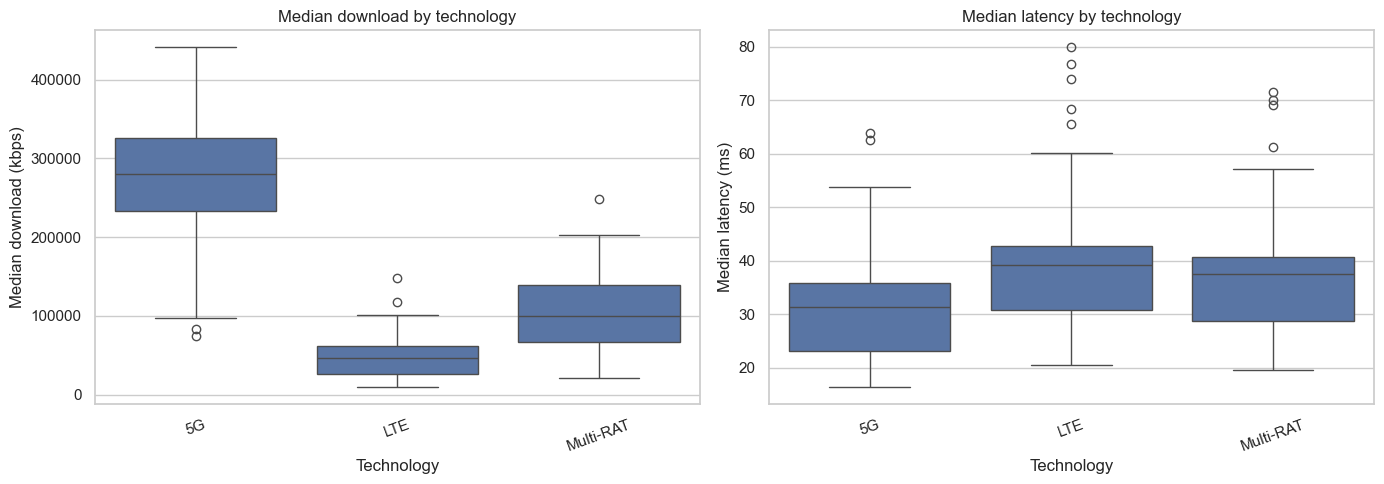

,technology_type,observations,avg_median_download_kbps,median_of_median_download_kbps,avg_median_latency_ms
0,5G,39,295221.272527,301663.240351,31.303517
2,Multi-RAT,39,105192.647187,111826.911023,35.828216
1,LTE,39,48988.431782,50829.594899,38.019918


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=analysis_df,
    x="technology_type",
    y="median_download_kbps_approx",
    ax=axes[0]
)
axes[0].set_title("Median download by technology")
axes[0].set_xlabel("Technology")
axes[0].set_ylabel("Median download (kbps)")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=analysis_df,
    x="technology_type",
    y="median_latency_ms_approx",
    ax=axes[1]
)
axes[1].set_title("Median latency by technology")
axes[1].set_xlabel("Technology")
axes[1].set_ylabel("Median latency (ms)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

tech_summary_df = (
    region_tech_week_df
    .groupby("technology_type", as_index=False)
    .agg(
        observations=("region", "size"),
        avg_median_download_kbps=("median_download_kbps", "mean"),
        median_of_median_download_kbps=("median_download_kbps", "median"),
        avg_median_latency_ms=("median_latency_ms", "mean"),
    )
    .sort_values("avg_median_download_kbps", ascending=False)
)

tech_summary_df


## Step 25 — Method A: Cross-sectional peer comparison inside each region-week-technology group

This is the main anomaly detection method for Project 6.

For each:

**`region × week × technology`**

we compare each carrier against the other carriers in the same peer group.

Because the preprocessing threshold can remove weak rows, we first keep only peer groups where all **three carriers** are present. This is not a sample-size threshold; it is a fairness rule. It prevents a carrier from being compared against only one remaining peer.

### Bad directions
- download **below** peer level is bad
- latency **above** peer level is bad

The anomaly score follows the slide formula:

**Cross-sectional Badness = max(0, −Download Gap (%)) + max(0, Latency Gap (%))**

So the score is measured in combined bad percentage-gap points.

### Threshold used for peer anomaly flags
We flag the top **5%** of peer badness scores using the **95th percentile**. This is suitable here because the peer table has hundreds of complete-peer rows, so a 95th-percentile cutoff keeps the anomaly log focused on the most severe region-carrier-technology cases instead of flooding the output with mild deviations.

In [7]:
peer_group_cols = ["aggregate_date", "region", "technology_type"]

peer_group_carrier_count_df = (
    analysis_df
    .groupby(peer_group_cols)["carrier_name"]
    .nunique()
    .reset_index(name="n_carriers_in_peer_group")
)

complete_peer_group_keys_df = peer_group_carrier_count_df[
    peer_group_carrier_count_df["n_carriers_in_peer_group"] == 3
][peer_group_cols].copy()

peer_input_df = analysis_df.merge(
    complete_peer_group_keys_df,
    on=peer_group_cols,
    how="inner"
)

print("Rows before complete-peer filtering:", len(analysis_df))
print("Rows used for peer comparison:", len(peer_input_df))
print("Rows excluded from peer comparison:", len(analysis_df) - len(peer_input_df))
print("Complete peer groups:", peer_input_df.groupby(peer_group_cols).ngroups)
print("Incomplete peer groups excluded:", (peer_group_carrier_count_df["n_carriers_in_peer_group"] < 3).sum())

carrier_peer_rows = []

for (week_value, region_value, tech_value), group_df in peer_input_df.groupby(peer_group_cols):
    for row_index, row in group_df.iterrows():
        peer_df = group_df[group_df["carrier_name"] != row["carrier_name"]].copy()

        peer_download = weighted_average(
            peer_df["median_download_kbps_approx"],
            peer_df["sample_count_total"]
        )
        peer_latency = weighted_average(
            peer_df["median_latency_ms_approx"],
            peer_df["sample_count_total"]
        )

        row_dict = row.to_dict()
        row_dict["peer_median_download_kbps"] = peer_download
        row_dict["peer_median_latency_ms"] = peer_latency
        row_dict["download_gap_kbps_vs_peer"] = row["median_download_kbps_approx"] - peer_download
        row_dict["latency_gap_ms_vs_peer"] = row["median_latency_ms_approx"] - peer_latency

        if pd.notna(peer_download) and peer_download != 0:
            row_dict["download_gap_pct_vs_peer"] = 100 * (
                row["median_download_kbps_approx"] - peer_download
            ) / peer_download
        else:
            row_dict["download_gap_pct_vs_peer"] = np.nan

        if pd.notna(peer_latency) and peer_latency != 0:
            row_dict["latency_gap_pct_vs_peer"] = 100 * (
                row["median_latency_ms_approx"] - peer_latency
            ) / peer_latency
        else:
            row_dict["latency_gap_pct_vs_peer"] = np.nan

        carrier_peer_rows.append(row_dict)

carrier_peer_df = pd.DataFrame(carrier_peer_rows)

# Keep the bad direction only, exactly as in the slide formula:
# Cross-sectional Badness = max(0, -Download Gap (%)) + max(0, Latency Gap (%))
carrier_peer_df["download_drop_vs_peer_pct"] = (
    -carrier_peer_df["download_gap_pct_vs_peer"]
).clip(lower=0)

carrier_peer_df["latency_rise_vs_peer_pct"] = (
    carrier_peer_df["latency_gap_pct_vs_peer"]
).clip(lower=0)

carrier_peer_df["peer_anomaly_score"] = (
    carrier_peer_df["download_drop_vs_peer_pct"]
    + carrier_peer_df["latency_rise_vs_peer_pct"]
)

# Use the 95th percentile as the anomaly threshold.
peer_score_threshold = carrier_peer_df["peer_anomaly_score"].quantile(0.95)
carrier_peer_df["peer_anomaly_flag"] = carrier_peer_df["peer_anomaly_score"] >= peer_score_threshold

print("\nCross-sectional badness score threshold (95th percentile):", round(peer_score_threshold, 4))
print("Number of flagged peer anomalies:", int(carrier_peer_df["peer_anomaly_flag"].sum()))

carrier_peer_df[
    [
        "week_label",
        "region",
        "carrier_name",
        "technology_type",
        "download_gap_pct_vs_peer",
        "latency_gap_pct_vs_peer",
        "download_drop_vs_peer_pct",
        "latency_rise_vs_peer_pct",
        "peer_anomaly_score",
        "peer_anomaly_flag",
    ]
].sort_values("peer_anomaly_score", ascending=False).head(10)


Rows before complete-peer filtering: 343
Rows used for peer comparison: 330
Rows excluded from peer comparison: 13
Complete peer groups: 110
Incomplete peer groups excluded: 7

Cross-sectional badness score threshold (95th percentile): 84.8949
Number of flagged peer anomalies: 17


,week_label,region,carrier_name,technology_type,download_gap_pct_vs_peer,latency_gap_pct_vs_peer,download_drop_vs_peer_pct,latency_rise_vs_peer_pct,peer_anomaly_score,peer_anomaly_flag
122,2026-03-08,Assiut,Operator C,LTE,-67.460418,70.646905,67.460418,70.646905,138.107323,True
11,2026-03-01,Assiut,Operator C,LTE,-52.026017,83.963769,52.026017,83.963769,135.989786,True
233,2026-03-15,Assiut,Operator C,LTE,-68.498296,66.786771,68.498296,66.786771,135.285068,True
173,2026-03-08,Ismailia,Operator C,LTE,-61.675278,69.116313,61.675278,69.116313,130.791590,True
62,2026-03-01,Ismailia,Operator C,LTE,-61.893571,64.369729,61.893571,64.369729,126.263300,True
5,2026-03-01,Alexandria,Operator C,LTE,-65.184627,57.856225,65.184627,57.856225,123.040852,True
266,2026-03-15,Gharbia,Operator C,LTE,-56.642649,63.214965,56.642649,63.214965,119.857614,True
284,2026-03-15,Ismailia,Operator C,LTE,-51.126470,57.457636,51.126470,57.457636,108.584106,True
299,2026-03-15,Monufia,Operator C,LTE,-55.962621,52.308554,55.962621,52.308554,108.271175,True
275,2026-03-15,Giza,Operator C,LTE,-65.769652,42.320548,65.769652,42.320548,108.090199,True


## Step 26 — Q1: Which carriers are consistently below the regional average for download speed across all three weeks?

We answer this using the peer-comparison table from Method A.

### Decision rule used here
A carrier will be treated as **consistently below the regional average** if:

1. its **average download gap vs peer** is negative in **each week**
2. its weekly **below-peer rate** is above **50%** in each week

The 50% threshold means the carrier must be below peers in the majority of comparable region-technology groups, not only in a few isolated cases. This is stricter than using only one overall average.

Carriers that are consistently below the regional peer average for download across all three weeks:
['Operator C']


,aggregate_date,week_label,carrier_name,observations,sample_count_total,below_peer_download_rate,weighted_below_peer_download_rate,avg_download_gap_pct_vs_peer,weighted_avg_download_gap_pct_vs_peer,median_download_gap_pct_vs_peer,above_peer_latency_rate,weighted_above_peer_latency_rate,avg_latency_gap_pct_vs_peer,weighted_avg_latency_gap_pct_vs_peer
0,2026-03-01,2026-03-01,Operator A,36,82780,0.528,0.443,24.610,29.939,-3.506,0.278,0.240,-8.981,-11.101
1,2026-03-01,2026-03-01,Operator B,36,306360,0.361,0.481,9.057,-5.539,11.516,0.500,0.661,1.708,10.990
2,2026-03-01,2026-03-01,Operator C,36,78577,0.750,0.727,-18.424,-12.134,-24.593,0.583,0.267,13.748,-4.122
3,2026-03-08,2026-03-08,Operator A,38,82431,0.500,0.505,19.743,28.659,-2.232,0.237,0.241,-8.130,-9.913
4,2026-03-08,2026-03-08,Operator B,38,291954,0.421,0.600,9.625,-4.726,15.371,0.605,0.749,1.677,12.473
5,2026-03-08,2026-03-08,Operator C,38,77058,0.632,0.569,-14.334,-6.920,-20.878,0.579,0.256,12.814,-4.562
6,2026-03-15,2026-03-15,Operator A,36,81161,0.361,0.493,28.603,27.078,13.661,0.278,0.291,-9.148,-10.511
7,2026-03-15,2026-03-15,Operator B,36,274874,0.389,0.432,8.056,-0.062,13.138,0.556,0.713,0.368,11.653
8,2026-03-15,2026-03-15,Operator C,36,70325,0.750,0.604,-21.603,-13.583,-28.358,0.694,0.322,17.282,-2.543


,carrier_name,observations,sample_count_total,below_peer_download_rate,weighted_below_peer_download_rate,avg_download_gap_pct_vs_peer,weighted_avg_download_gap_pct_vs_peer,median_download_gap_pct_vs_peer,above_peer_latency_rate,weighted_above_peer_latency_rate,avg_latency_gap_pct_vs_peer,weighted_avg_latency_gap_pct_vs_peer
2,Operator C,110,225960,0.709,0.635,-18.052,-10.807,-23.562,0.618,0.280,14.582,-3.781
1,Operator B,110,873188,0.391,0.506,8.926,-3.543,12.115,0.555,0.707,1.259,11.695
0,Operator A,110,246372,0.464,0.480,24.236,28.568,5.988,0.264,0.257,-8.742,-10.509


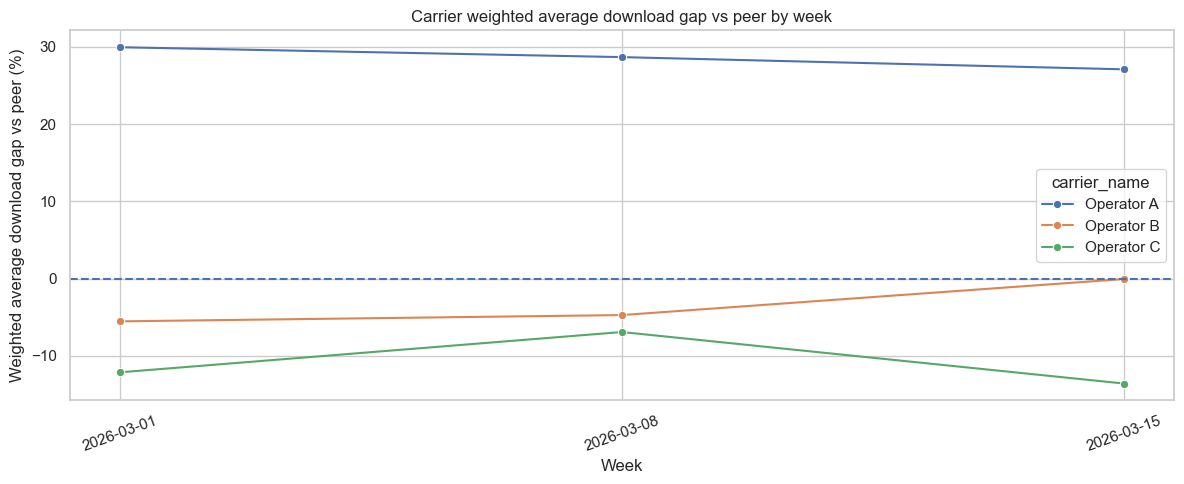

In [8]:
carrier_weekly_consistency_rows = []

for (date_value, week_value, carrier_value), group_df in carrier_peer_df.groupby(
    ["aggregate_date", "week_label", "carrier_name"]
):
    carrier_weekly_consistency_rows.append({
        "aggregate_date": date_value,
        "week_label": week_value,
        "carrier_name": carrier_value,
        "observations": len(group_df),
        "sample_count_total": group_df["sample_count_total"].sum(),
        "below_peer_download_rate": (group_df["download_gap_pct_vs_peer"] < 0).mean(),
        "weighted_below_peer_download_rate": weighted_average(
            (group_df["download_gap_pct_vs_peer"] < 0).astype(float),
            group_df["sample_count_total"]
        ),
        "avg_download_gap_pct_vs_peer": group_df["download_gap_pct_vs_peer"].mean(),
        "weighted_avg_download_gap_pct_vs_peer": weighted_average(
            group_df["download_gap_pct_vs_peer"],
            group_df["sample_count_total"]
        ),
        "median_download_gap_pct_vs_peer": group_df["download_gap_pct_vs_peer"].median(),
        "above_peer_latency_rate": (group_df["latency_gap_pct_vs_peer"] > 0).mean(),
        "weighted_above_peer_latency_rate": weighted_average(
            (group_df["latency_gap_pct_vs_peer"] > 0).astype(float),
            group_df["sample_count_total"]
        ),
        "avg_latency_gap_pct_vs_peer": group_df["latency_gap_pct_vs_peer"].mean(),
        "weighted_avg_latency_gap_pct_vs_peer": weighted_average(
            group_df["latency_gap_pct_vs_peer"],
            group_df["sample_count_total"]
        ),
    })

carrier_weekly_consistency_df = pd.DataFrame(carrier_weekly_consistency_rows)

carrier_overall_summary_rows = []

for carrier_value, group_df in carrier_peer_df.groupby("carrier_name"):
    carrier_overall_summary_rows.append({
        "carrier_name": carrier_value,
        "observations": len(group_df),
        "sample_count_total": group_df["sample_count_total"].sum(),
        "below_peer_download_rate": (group_df["download_gap_pct_vs_peer"] < 0).mean(),
        "weighted_below_peer_download_rate": weighted_average(
            (group_df["download_gap_pct_vs_peer"] < 0).astype(float),
            group_df["sample_count_total"]
        ),
        "avg_download_gap_pct_vs_peer": group_df["download_gap_pct_vs_peer"].mean(),
        "weighted_avg_download_gap_pct_vs_peer": weighted_average(
            group_df["download_gap_pct_vs_peer"],
            group_df["sample_count_total"]
        ),
        "median_download_gap_pct_vs_peer": group_df["download_gap_pct_vs_peer"].median(),
        "above_peer_latency_rate": (group_df["latency_gap_pct_vs_peer"] > 0).mean(),
        "weighted_above_peer_latency_rate": weighted_average(
            (group_df["latency_gap_pct_vs_peer"] > 0).astype(float),
            group_df["sample_count_total"]
        ),
        "avg_latency_gap_pct_vs_peer": group_df["latency_gap_pct_vs_peer"].mean(),
        "weighted_avg_latency_gap_pct_vs_peer": weighted_average(
            group_df["latency_gap_pct_vs_peer"],
            group_df["sample_count_total"]
        ),
    })

carrier_overall_summary_df = (
    pd.DataFrame(carrier_overall_summary_rows)
    .sort_values("weighted_below_peer_download_rate", ascending=False)
)

consistent_carriers = []
for carrier_value, group_df in carrier_weekly_consistency_df.groupby("carrier_name"):
    # The sign is the key consistency test. Weighted values are used for the main interpretation.
    negative_every_week = (group_df["weighted_avg_download_gap_pct_vs_peer"] < 0).all()
    below_peer_every_week = (group_df["weighted_below_peer_download_rate"] > 0.50).all()

    if negative_every_week and below_peer_every_week:
        consistent_carriers.append(carrier_value)

print("Carriers that are consistently below the regional peer average for download across all three weeks:")
print(consistent_carriers if consistent_carriers else "None")

display(carrier_weekly_consistency_df.round(3))
display(carrier_overall_summary_df.round(3))

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=carrier_weekly_consistency_df,
    x="week_label",
    y="weighted_avg_download_gap_pct_vs_peer",
    hue="carrier_name",
    marker="o"
)
plt.axhline(0, linestyle="--")
plt.title("Carrier weighted average download gap vs peer by week")
plt.xlabel("Week")
plt.ylabel("Weighted average download gap vs peer (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Step 27 — Q3: Which region-carrier pairs are outliers in their region?

Project 6 asks for carrier outliers **inside a region**.
So we summarize the cross-sectional peer results at the level:

**`region × carrier`**

The most useful columns here are:

- `avg_download_gap_pct_vs_peer`
- `avg_latency_gap_pct_vs_peer`
- `below_peer_download_rate`
- `avg_peer_anomaly_score`

The larger the `avg_peer_anomaly_score`, the more often and/or more severely that carrier looked weak relative to its regional peers. Because the score is now the slide formula, it is measured in combined bad percentage-gap points.


,region,carrier_name,observations,sample_count_total,avg_median_download_kbps,avg_median_latency_ms,below_peer_download_rate,above_peer_latency_rate,avg_download_gap_pct_vs_peer,avg_latency_gap_pct_vs_peer,avg_peer_anomaly_score,flagged_peer_anomalies
2,Alexandria,Operator C,9,2600,145667.671,41.964,0.889,1.000,-21.403,18.061,44.658,1
0,Alexandria,Operator A,9,2185,134547.167,30.622,0.556,0.000,-5.086,-19.148,12.228,0
1,Alexandria,Operator B,9,13836,152361.563,36.803,0.222,0.667,22.773,-0.532,2.531,0
5,Assiut,Operator C,7,1541,136906.271,71.687,0.714,1.000,-23.130,68.845,94.352,4
3,Assiut,Operator A,7,816,87572.651,51.675,0.857,0.857,-25.740,7.174,40.201,0
4,Assiut,Operator B,7,5544,161611.281,41.186,0.143,0.000,44.662,-36.163,0.547,0
7,Cairo,Operator B,9,50932,88593.551,37.551,1.000,1.000,-36.217,26.027,62.243,1
8,Cairo,Operator C,9,15745,165163.211,28.903,0.333,0.111,39.569,-16.731,8.037,0
6,Cairo,Operator A,9,15956,127820.432,29.668,0.000,0.000,47.633,-16.226,0.000,0
10,Dakahlia,Operator B,9,195221,91066.611,35.031,0.667,1.000,-24.111,42.167,69.732,0


Worst carrier identified per region:


,region,carrier_name,avg_download_gap_pct_vs_peer,avg_latency_gap_pct_vs_peer,avg_peer_anomaly_score,flagged_peer_anomalies
5,Assiut,Operator C,-23.130,68.845,94.352,4
29,Monufia,Operator C,-42.196,33.052,75.704,3
10,Dakahlia,Operator B,-24.111,42.167,69.732,0
17,Gharbia,Operator C,-9.313,46.072,66.412,2
23,Ismailia,Operator C,-10.725,46.478,64.509,3
20,Giza,Operator C,-36.377,27.092,63.469,3
7,Cairo,Operator B,-36.217,26.027,62.243,1
34,Sharqia,Operator B,-45.671,10.702,59.458,0
14,Fayoum,Operator C,-34.068,16.010,50.087,0
2,Alexandria,Operator C,-21.403,18.061,44.658,1


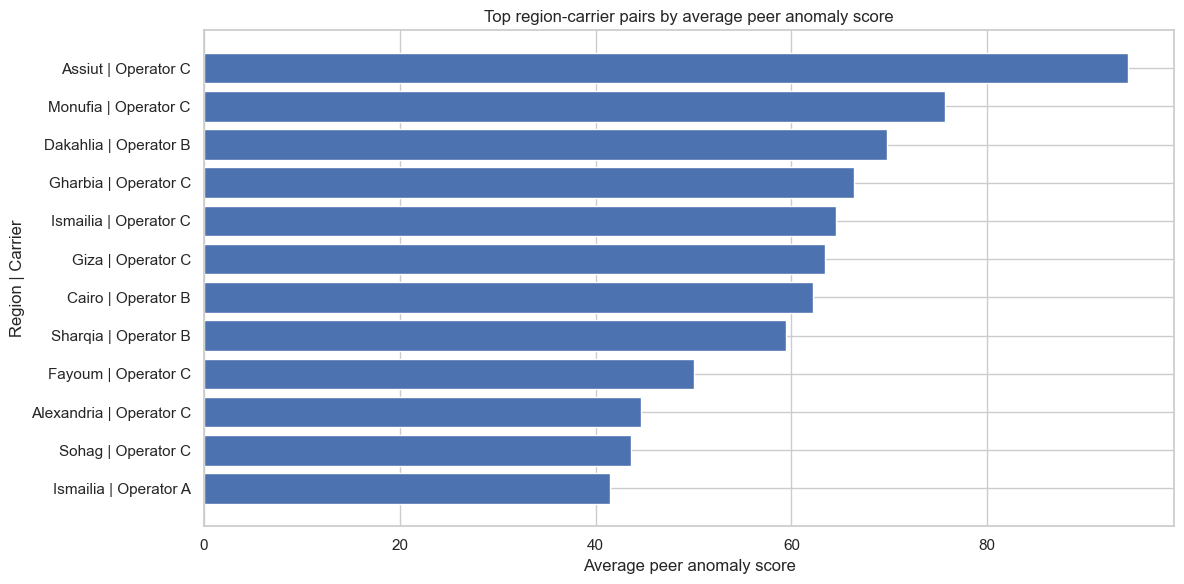

In [9]:
region_carrier_summary_rows = []

for (region_value, carrier_value), group_df in carrier_peer_df.groupby(["region", "carrier_name"]):
    row_dict = {
        "region": region_value,
        "carrier_name": carrier_value,
        "observations": len(group_df),
        "sample_count_total": group_df["sample_count_total"].sum(),
        "avg_median_download_kbps": weighted_average(
            group_df["median_download_kbps_approx"],
            group_df["sample_count_total"]
        ),
        "avg_median_latency_ms": weighted_average(
            group_df["median_latency_ms_approx"],
            group_df["sample_count_total"]
        ),
        "below_peer_download_rate": (group_df["download_gap_pct_vs_peer"] < 0).mean(),
        "above_peer_latency_rate": (group_df["latency_gap_pct_vs_peer"] > 0).mean(),
        "avg_download_gap_pct_vs_peer": weighted_average(
            group_df["download_gap_pct_vs_peer"],
            group_df["sample_count_total"]
        ),
        "avg_latency_gap_pct_vs_peer": weighted_average(
            group_df["latency_gap_pct_vs_peer"],
            group_df["sample_count_total"]
        ),
        "avg_peer_anomaly_score": weighted_average(
            group_df["peer_anomaly_score"],
            group_df["sample_count_total"]
        ),
        "flagged_peer_anomalies": int(group_df["peer_anomaly_flag"].sum()),
    }
    region_carrier_summary_rows.append(row_dict)

region_carrier_summary_df = pd.DataFrame(region_carrier_summary_rows)

# Worst carrier in each region = highest average peer anomaly score.
worst_carrier_by_region_df = (
    region_carrier_summary_df
    .sort_values(["region", "avg_peer_anomaly_score"], ascending=[True, False])
    .groupby("region", as_index=False)
    .head(1)
    .sort_values("avg_peer_anomaly_score", ascending=False)
)

display(
    region_carrier_summary_df
    .sort_values(["region", "avg_peer_anomaly_score"], ascending=[True, False])
    .round(3)
)

print("Worst carrier identified per region:")
display(
    worst_carrier_by_region_df[
        [
            "region",
            "carrier_name",
            "avg_download_gap_pct_vs_peer",
            "avg_latency_gap_pct_vs_peer",
            "avg_peer_anomaly_score",
            "flagged_peer_anomalies",
        ]
    ].round(3)
)

plt.figure(figsize=(12, 6))
top_region_carrier_df = (
    region_carrier_summary_df
    .sort_values("avg_peer_anomaly_score", ascending=True)
    .tail(12)
    .copy()
)
top_region_carrier_df["region_carrier_label"] = (
    top_region_carrier_df["region"] + " | " + top_region_carrier_df["carrier_name"]
)

plt.barh(
    top_region_carrier_df["region_carrier_label"],
    top_region_carrier_df["avg_peer_anomaly_score"]
)
plt.title("Top region-carrier pairs by average peer anomaly score")
plt.xlabel("Average peer anomaly score")
plt.ylabel("Region | Carrier")
plt.tight_layout()
plt.show()


## Step 28 — Method B: Week-over-week change analysis at the regional level

Cross-sectional comparison is the main method for Project 6, but the project also asks us to look for
**week-over-week change**.

Because there are only 3 weeks, we do **not** use long-history models.
Instead, we compute the change between:

- week 1 → week 2
- week 2 → week 3

### Bad directions for Method B
- a **download drop** is bad
- a **latency rise** is bad

For the combined change score, we rank only positive badness values. A row with no download drop should receive zero contribution from the download side, and a row with no latency rise should receive zero contribution from the latency side.

### Threshold used for week-over-week anomaly flags
There are only **26 region transitions** total because we have 13 regions and 2 week-to-week transitions. For that small table, a 95th-percentile cutoff would be too strict and would flag only about one or two rows. Therefore we use the **90th percentile**, which keeps the combined-change anomaly log small while still allowing a few meaningful regional deterioration cases to appear.

In [10]:
region_overall_week_df = region_overall_week_df.sort_values(["region", "aggregate_date"]).copy()

region_overall_week_df["download_pct_change"] = (
    region_overall_week_df.groupby("region")["median_download_kbps"].pct_change() * 100
)
region_overall_week_df["latency_pct_change"] = (
    region_overall_week_df.groupby("region")["median_latency_ms"].pct_change() * 100
)
region_overall_week_df["download_abs_change_kbps"] = (
    region_overall_week_df.groupby("region")["median_download_kbps"].diff()
)
region_overall_week_df["latency_abs_change_ms"] = (
    region_overall_week_df.groupby("region")["median_latency_ms"].diff()
)

region_change_df = region_overall_week_df.dropna(
    subset=["download_pct_change", "latency_pct_change"]
).copy()

region_change_df["download_drop_pct"] = (-region_change_df["download_pct_change"]).clip(lower=0)
region_change_df["latency_rise_pct"] = (region_change_df["latency_pct_change"]).clip(lower=0)

region_change_df["download_drop_pct_rank"] = (
    region_change_df
    .groupby("aggregate_date")["download_drop_pct"]
    .transform(positive_percentile_rank)
)
region_change_df["latency_rise_pct_rank"] = (
    region_change_df
    .groupby("aggregate_date")["latency_rise_pct"]
    .transform(positive_percentile_rank)
)

region_change_df["change_anomaly_score"] = (
    region_change_df["download_drop_pct_rank"] + region_change_df["latency_rise_pct_rank"]
)

change_score_threshold = region_change_df["change_anomaly_score"].quantile(0.90)
region_change_df["change_anomaly_flag"] = region_change_df["change_anomaly_score"] >= change_score_threshold

print("Week-over-week change score threshold (90th percentile):", round(change_score_threshold, 4))
print("Number of flagged change anomalies:", int(region_change_df["change_anomaly_flag"].sum()))

region_change_df[
    [
        "region",
        "week_label",
        "download_pct_change",
        "latency_pct_change",
        "change_anomaly_score",
        "change_anomaly_flag",
    ]
].sort_values("change_anomaly_score", ascending=False).head(10)


Week-over-week change score threshold (90th percentile): 1.3194
Number of flagged change anomalies: 3


,region,week_label,download_pct_change,latency_pct_change,change_anomaly_score,change_anomaly_flag
16,Dakahlia,2026-03-08,-10.980717,2.860717,1.611111,True
29,Dakahlia,2026-03-15,-6.325005,4.084742,1.388889,True
23,Port Said,2026-03-08,-7.344897,2.696092,1.333333,True
31,Gharbia,2026-03-15,-13.289068,2.194202,1.305556,False
34,Minya,2026-03-15,-12.960612,2.218942,1.291667,False
35,Monufia,2026-03-15,-13.311112,1.265788,1.208333,False
24,Sharqia,2026-03-08,-0.149602,3.103121,1.055556,False
13,Alexandria,2026-03-08,-12.927838,-1.285424,1.000000,False
22,Monufia,2026-03-08,9.777555,4.845504,1.000000,False
38,Sohag,2026-03-15,9.549506,4.727688,1.000000,False


## Step 29 — Q2: Which regions show the largest week-over-week change in download speed or latency?

We answer this from the regional change table.

To keep the interpretation simple, we show:

1. the largest **download drops**
2. the largest **latency rises**
3. the combined week-over-week anomaly score

The `TOP_N = 5` value is a reporting threshold, not a statistical anomaly threshold. It directly matches the project style of showing the most important named examples while keeping the table readable.

Largest week-over-week download drops:


,region,week_label,download_pct_change,download_abs_change_kbps,top_download_drop_flag
27,Assiut,2026-03-15,-14.544,-28016.917,True
35,Monufia,2026-03-15,-13.311,-18533.101,True
31,Gharbia,2026-03-15,-13.289,-27356.815,True
34,Minya,2026-03-15,-12.961,-16764.634,True
13,Alexandria,2026-03-08,-12.928,-21352.982,True
16,Dakahlia,2026-03-08,-10.981,-12119.954,False
23,Port Said,2026-03-08,-7.345,-14319.051,False
29,Dakahlia,2026-03-15,-6.325,-6214.629,False
19,Giza,2026-03-08,-6.319,-9912.161,False
26,Alexandria,2026-03-15,-4.228,-6081.072,False


Largest week-over-week latency rises:


,region,week_label,latency_pct_change,latency_abs_change_ms,top_latency_rise_flag
22,Monufia,2026-03-08,4.846,1.675,True
38,Sohag,2026-03-15,4.728,1.793,True
29,Dakahlia,2026-03-15,4.085,1.228,True
30,Fayoum,2026-03-15,3.236,1.300,True
24,Sharqia,2026-03-08,3.103,1.192,True
16,Dakahlia,2026-03-08,2.861,0.836,False
23,Port Said,2026-03-08,2.696,0.630,False
18,Gharbia,2026-03-08,2.314,0.999,False
34,Minya,2026-03-15,2.219,0.953,False
31,Gharbia,2026-03-15,2.194,0.969,False


Combined week-over-week anomalies:


,region,week_label,download_pct_change,latency_pct_change,change_anomaly_score,combined_change_anomaly_flag
16,Dakahlia,2026-03-08,-10.981,2.861,1.611,True
29,Dakahlia,2026-03-15,-6.325,4.085,1.389,True
23,Port Said,2026-03-08,-7.345,2.696,1.333,True
31,Gharbia,2026-03-15,-13.289,2.194,1.306,False
34,Minya,2026-03-15,-12.961,2.219,1.292,False
35,Monufia,2026-03-15,-13.311,1.266,1.208,False
24,Sharqia,2026-03-08,-0.150,3.103,1.056,False
13,Alexandria,2026-03-08,-12.928,-1.285,1.000,False
22,Monufia,2026-03-08,9.778,4.846,1.000,False
38,Sohag,2026-03-15,9.550,4.728,1.000,False


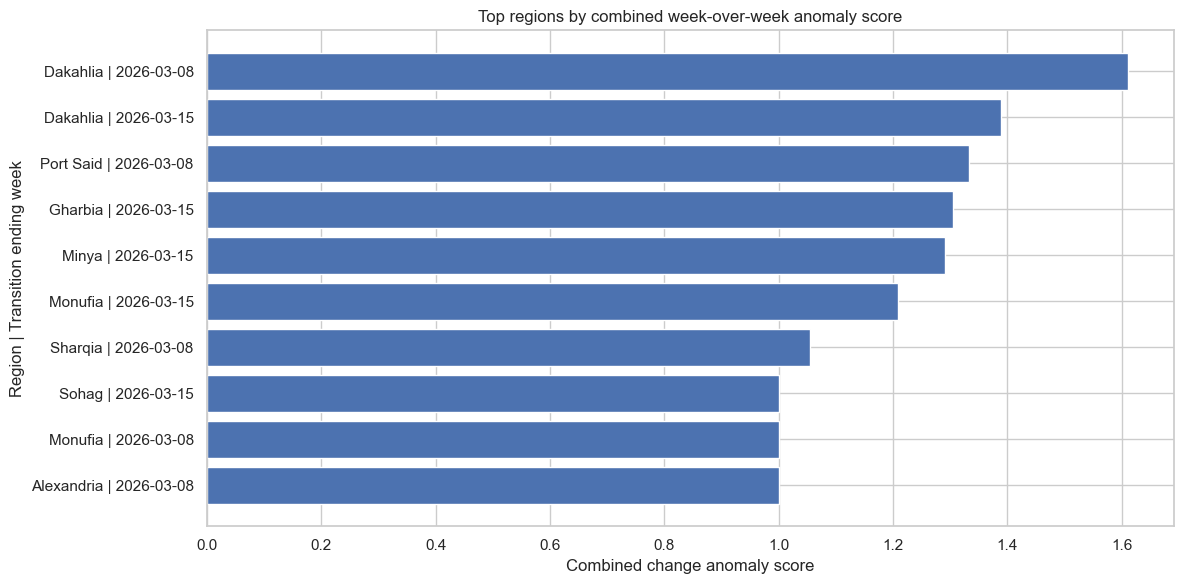

In [11]:
# Separate direct-answer tables for Q2.
# These are intentionally kept separate from the combined anomaly score because a region can have
# a large download drop without a latency rise, or a large latency rise without a download drop.
TOP_N = 5

region_change_df["top_download_drop_flag"] = False
region_change_df.loc[
    region_change_df.sort_values("download_pct_change").head(TOP_N).index,
    "top_download_drop_flag"
] = True

region_change_df["top_latency_rise_flag"] = False
region_change_df.loc[
    region_change_df.sort_values("latency_pct_change", ascending=False).head(TOP_N).index,
    "top_latency_rise_flag"
] = True

region_change_df["combined_change_anomaly_flag"] = region_change_df["change_anomaly_flag"]

largest_download_drop_df = (
    region_change_df
    .sort_values("download_pct_change")
    .loc[:, ["region", "week_label", "download_pct_change", "download_abs_change_kbps", "top_download_drop_flag"]]
    .head(10)
)

largest_latency_rise_df = (
    region_change_df
    .sort_values("latency_pct_change", ascending=False)
    .loc[:, ["region", "week_label", "latency_pct_change", "latency_abs_change_ms", "top_latency_rise_flag"]]
    .head(10)
)

combined_change_anomalies_df = (
    region_change_df
    .sort_values("change_anomaly_score", ascending=False)
    .loc[:, ["region", "week_label", "download_pct_change", "latency_pct_change", "change_anomaly_score", "combined_change_anomaly_flag"]]
    .head(10)
)

print("Largest week-over-week download drops:")
display(largest_download_drop_df.round(3))

print("Largest week-over-week latency rises:")
display(largest_latency_rise_df.round(3))

print("Combined week-over-week anomalies:")
display(combined_change_anomalies_df.round(3))

plt.figure(figsize=(12, 6))
plot_change_df = combined_change_anomalies_df.sort_values("change_anomaly_score", ascending=True).copy()
plot_change_df["region_week_label"] = plot_change_df["region"] + " | " + plot_change_df["week_label"]

plt.barh(
    plot_change_df["region_week_label"],
    plot_change_df["change_anomaly_score"]
)
plt.title("Top regions by combined week-over-week anomaly score")
plt.xlabel("Combined change anomaly score")
plt.ylabel("Region | Transition ending week")
plt.tight_layout()
plt.show()


## Step 30 — Q4: Is the 5G performance distribution different from LTE across regions?

To answer this, we compare **region-level** 5G and LTE performance after aggregating across carriers.

### Why not compare raw carrier rows directly?
Because Q4 asks about the **technology distribution across regions**.
So we first create one value per:

**`region × week × technology`**


How many region-week observations have both LTE and 5G?
39

How many times does 5G underperform LTE at region-week level?
0


technology_type,week_label,region,LTE,5G,fiveg_minus_lte_kbps,fiveg_minus_lte_pct,fiveg_underperform_lte
17,2026-03-08,Fayoum,33316.562947,197472.624490,164156.061543,492.716076,False
30,2026-03-15,Fayoum,36815.282987,205315.153653,168499.870666,457.690005,False
38,2026-03-15,Sohag,20713.240083,194795.615473,174082.375391,840.440099,False
35,2026-03-15,Monufia,61692.687307,243327.464103,181634.776796,294.418649,False
4,2026-03-01,Fayoum,27504.693620,218953.103135,191448.409515,696.057234,False
34,2026-03-15,Minya,48126.813597,244099.070370,195972.256773,407.199734,False
25,2026-03-08,Sohag,18494.904949,218846.157169,200351.252220,1083.278085,False
11,2026-03-01,Sharqia,21036.136601,230351.096252,209314.959650,995.025672,False
37,2026-03-15,Sharqia,21880.580125,233281.486678,211400.906552,966.157686,False
24,2026-03-08,Sharqia,19528.460608,236901.910334,217373.449726,1113.111034,False



Matched carrier-region-week LTE vs 5G cases:
109

How many times does 5G underperform LTE in matched carrier-region-week cases?
0


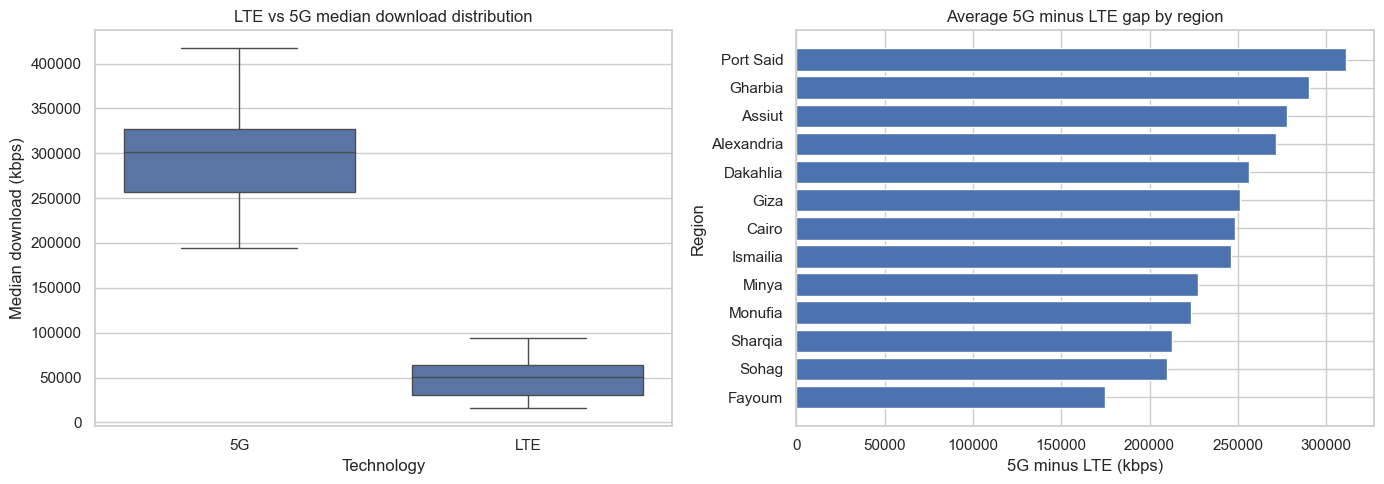

In [12]:
fiveg_lte_pivot_df = (
    region_tech_week_df
    .pivot_table(
        index=["aggregate_date", "week_label", "region"],
        columns="technology_type",
        values="median_download_kbps"
    )
    .reset_index()
)

# Keep only rows where both LTE and 5G exist.
fiveg_lte_pivot_df = fiveg_lte_pivot_df.dropna(subset=["LTE", "5G"]).copy()
fiveg_lte_pivot_df["fiveg_minus_lte_kbps"] = fiveg_lte_pivot_df["5G"] - fiveg_lte_pivot_df["LTE"]
fiveg_lte_pivot_df["fiveg_minus_lte_pct"] = 100 * (
    fiveg_lte_pivot_df["5G"] - fiveg_lte_pivot_df["LTE"]
) / fiveg_lte_pivot_df["LTE"]
fiveg_lte_pivot_df["fiveg_underperform_lte"] = fiveg_lte_pivot_df["fiveg_minus_lte_kbps"] < 0

print("How many region-week observations have both LTE and 5G?")
print(len(fiveg_lte_pivot_df))

print("\nHow many times does 5G underperform LTE at region-week level?")
print(int(fiveg_lte_pivot_df["fiveg_underperform_lte"].sum()))

display(
    fiveg_lte_pivot_df[
        [
            "week_label",
            "region",
            "LTE",
            "5G",
            "fiveg_minus_lte_kbps",
            "fiveg_minus_lte_pct",
            "fiveg_underperform_lte",
        ]
    ].sort_values("fiveg_minus_lte_kbps")
)

# Stronger matched check: compare LTE and 5G inside the same region × week × carrier.
fiveg_lte_matched_carrier_df = (
    analysis_df
    .pivot_table(
        index=["aggregate_date", "week_label", "region", "carrier_name"],
        columns="technology_type",
        values="median_download_kbps_approx"
    )
    .reset_index()
    .dropna(subset=["LTE", "5G"])
    .copy()
)

fiveg_lte_matched_carrier_df["fiveg_minus_lte_kbps"] = (
    fiveg_lte_matched_carrier_df["5G"] - fiveg_lte_matched_carrier_df["LTE"]
)
fiveg_lte_matched_carrier_df["fiveg_minus_lte_pct"] = 100 * (
    fiveg_lte_matched_carrier_df["5G"] - fiveg_lte_matched_carrier_df["LTE"]
) / fiveg_lte_matched_carrier_df["LTE"]
fiveg_lte_matched_carrier_df["fiveg_underperform_lte"] = (
    fiveg_lte_matched_carrier_df["fiveg_minus_lte_kbps"] < 0
)

print("\nMatched carrier-region-week LTE vs 5G cases:")
print(len(fiveg_lte_matched_carrier_df))

print("\nHow many times does 5G underperform LTE in matched carrier-region-week cases?")
print(int(fiveg_lte_matched_carrier_df["fiveg_underperform_lte"].sum()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=region_tech_week_df[region_tech_week_df["technology_type"].isin(["LTE", "5G"])],
    x="technology_type",
    y="median_download_kbps",
    ax=axes[0]
)
axes[0].set_title("LTE vs 5G median download distribution")
axes[0].set_xlabel("Technology")
axes[0].set_ylabel("Median download (kbps)")

mean_fiveg_lte_gap_df = (
    fiveg_lte_pivot_df
    .groupby("region", as_index=False)["fiveg_minus_lte_kbps"]
    .mean()
    .sort_values("fiveg_minus_lte_kbps", ascending=True)
)

axes[1].barh(
    mean_fiveg_lte_gap_df["region"],
    mean_fiveg_lte_gap_df["fiveg_minus_lte_kbps"]
)
axes[1].set_title("Average 5G minus LTE gap by region")
axes[1].set_xlabel("5G minus LTE (kbps)")
axes[1].set_ylabel("Region")

plt.tight_layout()
plt.show()


## Step 31 — Q5: Build the region ranking based on median download speed

Project 6 asks us to rank all 13 regions from best to worst and then study:

- whether the ranking stays stable
- which region is the most unstable

We use the `region_overall_week_df` table because the ranking question is about **regions overall**, not about a single carrier or technology.


Most unstable region by ranking movement:


week_label,region,2026-03-01,2026-03-08,2026-03-15,rank_range,total_abs_rank_movement
10,Port Said,1.0,3.0,1.0,2.0,4.0


,week_label,region,median_download_kbps,rank
10,2026-03-01,Port Said,194952.365883,1.0
5,2026-03-01,Gharbia,190226.977028,2.0
1,2026-03-01,Assiut,166339.671761,3.0
0,2026-03-01,Alexandria,165170.554728,4.0
6,2026-03-01,Giza,156870.525485,5.0
7,2026-03-01,Ismailia,142906.481627,6.0
8,2026-03-01,Minya,129038.112311,7.0
9,2026-03-01,Monufia,126829.473498,8.0
3,2026-03-01,Dakahlia,110374.885658,9.0
2,2026-03-01,Cairo,104008.770538,10.0


week_label,region,2026-03-01,2026-03-08,2026-03-15,rank_range,total_abs_rank_movement
10,Port Said,1.0,3.0,1.0,2.0,4.0
0,Alexandria,4.0,5.0,6.0,2.0,2.0
2,Cairo,10.0,9.0,8.0,2.0,2.0
8,Minya,7.0,8.0,9.0,2.0,2.0
1,Assiut,3.0,2.0,3.0,1.0,2.0
5,Gharbia,2.0,1.0,2.0,1.0,2.0
3,Dakahlia,9.0,10.0,10.0,1.0,1.0
4,Fayoum,12.0,11.0,11.0,1.0,1.0
6,Giza,5.0,4.0,4.0,1.0,1.0
7,Ismailia,6.0,6.0,5.0,1.0,1.0


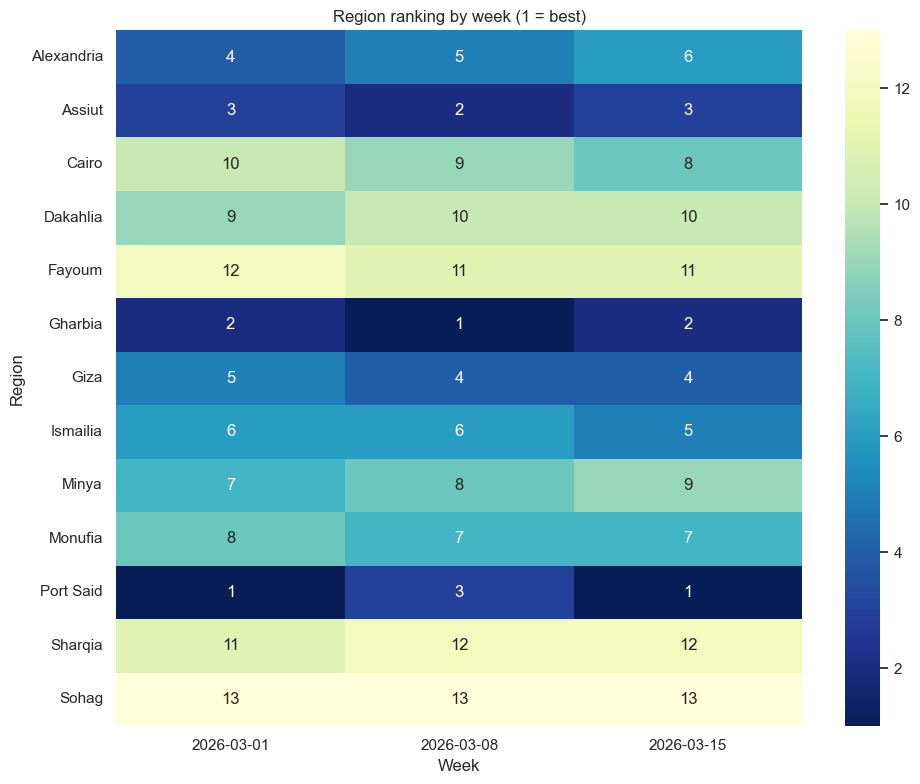

In [13]:
region_ranking_df = region_overall_week_df.copy()
region_ranking_df["rank"] = (
    region_ranking_df
    .groupby("aggregate_date")["median_download_kbps"]
    .rank(method="dense", ascending=False)
)

region_ranking_pivot_df = (
    region_ranking_df
    .pivot_table(
        index="region",
        columns="week_label",
        values="rank"
    )
    .reset_index()
)

rank_value_cols = [col for col in region_ranking_pivot_df.columns if col != "region"]

region_ranking_pivot_df["rank_range"] = region_ranking_pivot_df[rank_value_cols].max(axis=1) - region_ranking_pivot_df[rank_value_cols].min(axis=1)
region_ranking_pivot_df["total_abs_rank_movement"] = (
    region_ranking_pivot_df[rank_value_cols]
    .diff(axis=1)
    .abs()
    .sum(axis=1)
)

most_unstable_region_df = (
    region_ranking_pivot_df
    .sort_values(["total_abs_rank_movement", "rank_range"], ascending=False)
    .head(1)
)

print("Most unstable region by ranking movement:")
display(most_unstable_region_df)

display(
    region_ranking_df[
        ["week_label", "region", "median_download_kbps", "rank"]
    ].sort_values(["week_label", "rank"])
)

display(
    region_ranking_pivot_df
    .sort_values(["total_abs_rank_movement", "rank_range"], ascending=False)
)

heatmap_df = (
    region_ranking_df
    .pivot_table(index="region", columns="week_label", values="rank")
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu_r"
)
plt.title("Region ranking by week (1 = best)")
plt.xlabel("Week")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


## Step 32 — Mean vs median divergence analysis

Project 6 explicitly asks us to explain what it means when the mean and median diverge.

### Why this matters
If the mean is much higher than the median, that often suggests:
- right-skew
- a long tail of unusually high observations
- outliers pulling the average upward

If the mean is much lower than the median, that suggests the opposite pattern.

Because the cleaned file already contains:
- `download_median_gap_pct`
- `latency_median_gap_pct`

we can directly find the strongest divergence examples.


Top download mean-vs-median divergence examples:


,week_label,region,carrier_name,technology_type,sample_count_total,mean_download_kbps,median_download_kbps_approx,download_median_gap_pct
109,2026-03-01,Sohag,Operator B,Multi-RAT,7699,85102.581,22048.459,285.980
225,2026-03-08,Sohag,Operator B,Multi-RAT,5016,77237.581,25142.464,207.200
216,2026-03-08,Sharqia,Operator B,Multi-RAT,16446,85559.357,28034.154,205.197
100,2026-03-01,Sharqia,Operator B,Multi-RAT,19150,86252.881,28503.070,202.609
330,2026-03-15,Sharqia,Operator B,Multi-RAT,14214,88466.168,29902.369,195.850
339,2026-03-15,Sohag,Operator B,Multi-RAT,3279,88798.210,30904.274,187.333
145,2026-03-08,Dakahlia,Operator B,Multi-RAT,33137,145701.708,51225.271,184.433
260,2026-03-15,Dakahlia,Operator B,Multi-RAT,35859,136669.578,48447.857,182.096
31,2026-03-01,Dakahlia,Operator B,Multi-RAT,28353,162939.432,66866.936,143.677
108,2026-03-01,Sohag,Operator B,LTE,6059,35259.684,15128.128,133.074


Top latency mean-vs-median divergence examples:


,week_label,region,carrier_name,technology_type,sample_count_total,mean_latency_ms,median_latency_ms_approx,latency_median_gap_pct
92,2026-03-01,Port Said,Operator C,5G,8170,25.247,16.439,53.573
138,2026-03-08,Cairo,Operator C,LTE,1132,54.422,35.774,52.129
94,2026-03-01,Port Said,Operator C,Multi-RAT,12846,29.954,19.971,49.982
208,2026-03-08,Port Said,Operator C,5G,7776,23.528,16.373,43.704
93,2026-03-01,Port Said,Operator C,LTE,5025,36.936,25.745,43.469
322,2026-03-15,Port Said,Operator C,5G,6751,24.614,17.464,40.944
210,2026-03-08,Port Said,Operator C,Multi-RAT,12188,28.067,20.090,39.708
139,2026-03-08,Cairo,Operator C,Multi-RAT,2682,40.639,29.215,39.103
332,2026-03-15,Sharqia,Operator C,LTE,868,58.164,41.884,38.869
137,2026-03-08,Cairo,Operator C,5G,1613,30.142,22.223,35.633


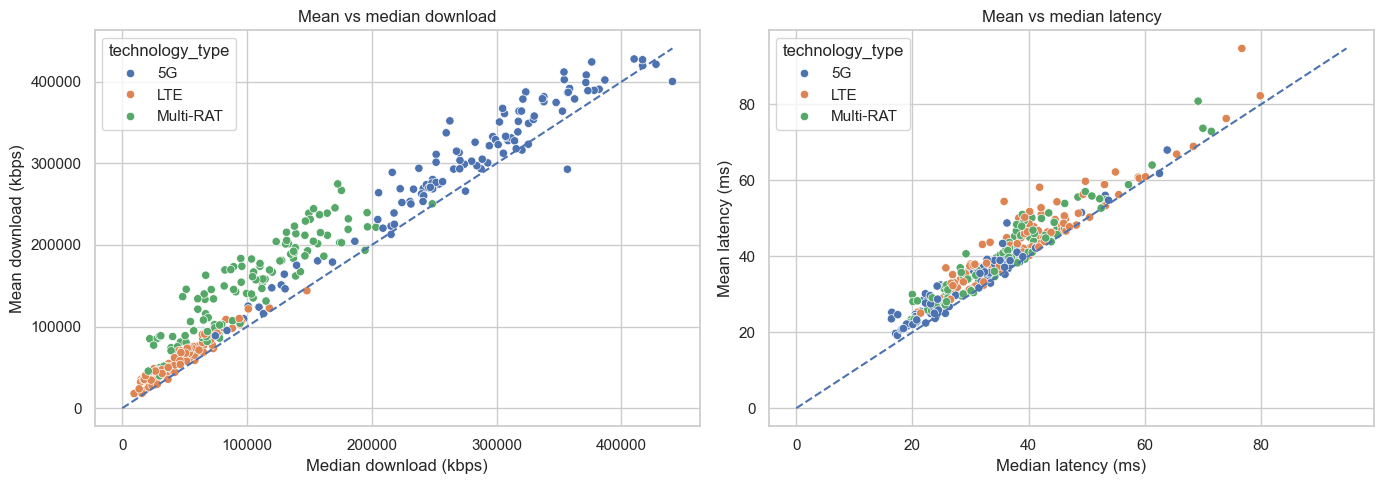

In [14]:
download_gap_examples_df = (
    analysis_df[
        [
            "week_label",
            "region",
            "carrier_name",
            "technology_type",
            "sample_count_total",
            "mean_download_kbps",
            "median_download_kbps_approx",
            "download_median_gap_pct",
        ]
    ]
    .sort_values("download_median_gap_pct", ascending=False)
    .head(10)
)

latency_gap_examples_df = (
    analysis_df[
        [
            "week_label",
            "region",
            "carrier_name",
            "technology_type",
            "sample_count_total",
            "mean_latency_ms",
            "median_latency_ms_approx",
            "latency_median_gap_pct",
        ]
    ]
    .sort_values("latency_median_gap_pct", ascending=False)
    .head(10)
)

print("Top download mean-vs-median divergence examples:")
display(download_gap_examples_df.round(3))

print("Top latency mean-vs-median divergence examples:")
display(latency_gap_examples_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=analysis_df,
    x="median_download_kbps_approx",
    y="mean_download_kbps",
    hue="technology_type",
    ax=axes[0]
)
max_download_value = max(
    analysis_df["median_download_kbps_approx"].max(),
    analysis_df["mean_download_kbps"].max()
)
axes[0].plot([0, max_download_value], [0, max_download_value], linestyle="--")
axes[0].set_title("Mean vs median download")
axes[0].set_xlabel("Median download (kbps)")
axes[0].set_ylabel("Mean download (kbps)")

sns.scatterplot(
    data=analysis_df,
    x="median_latency_ms_approx",
    y="mean_latency_ms",
    hue="technology_type",
    ax=axes[1]
)
max_latency_value = max(
    analysis_df["median_latency_ms_approx"].max(),
    analysis_df["mean_latency_ms"].max()
)
axes[1].plot([0, max_latency_value], [0, max_latency_value], linestyle="--")
axes[1].set_title("Mean vs median latency")
axes[1].set_xlabel("Median latency (ms)")
axes[1].set_ylabel("Mean latency (ms)")

plt.tight_layout()
plt.show()


## Step 33 — Build the carrier report and other slide-ready tables

Project 6 asks for a **carrier report**, a **region ranking**, and a **mean-vs-median analysis**.

Here we prepare clean export tables that you can also reuse in your slides or README.


In [15]:
carrier_report_df = (
    region_carrier_summary_df
    .sort_values(["region", "avg_peer_anomaly_score"], ascending=[True, False])
    .copy()
)

# Keep separate definitions because "worst" can mean different things.
carrier_report_df["is_worst_by_download_in_region"] = False
carrier_report_df.loc[
    carrier_report_df.groupby("region")["avg_median_download_kbps"].idxmin(),
    "is_worst_by_download_in_region"
] = True

carrier_report_df["is_worst_by_latency_in_region"] = False
carrier_report_df.loc[
    carrier_report_df.groupby("region")["avg_median_latency_ms"].idxmax(),
    "is_worst_by_latency_in_region"
] = True

carrier_report_df["is_worst_by_peer_anomaly_score_in_region"] = False
carrier_report_df.loc[
    carrier_report_df.groupby("region")["avg_peer_anomaly_score"].idxmax(),
    "is_worst_by_peer_anomaly_score_in_region"
] = True

# Backward-compatible column name:
# this means worst by peer anomaly score, not necessarily lowest absolute download.
carrier_report_df["is_worst_carrier_in_region"] = carrier_report_df["is_worst_by_peer_anomaly_score_in_region"]

region_ranking_export_df = (
    region_ranking_df[
        ["week_label", "region", "median_download_kbps", "rank"]
    ]
    .sort_values(["week_label", "rank"])
    .copy()
)

rank_stability_df = (
    region_ranking_pivot_df
    .sort_values(["total_abs_rank_movement", "rank_range"], ascending=False)
    .copy()
)

mean_median_examples_df = pd.concat(
    [
        download_gap_examples_df.assign(example_type="download_gap"),
        latency_gap_examples_df.assign(example_type="latency_gap"),
    ],
    ignore_index=True,
    sort=False
)

display(carrier_report_df.round(3).head(20))
display(region_ranking_export_df.round(3).head(20))
display(rank_stability_df.round(3))
display(mean_median_examples_df.round(3).head(10))


,region,carrier_name,observations,sample_count_total,avg_median_download_kbps,avg_median_latency_ms,below_peer_download_rate,above_peer_latency_rate,avg_download_gap_pct_vs_peer,avg_latency_gap_pct_vs_peer,avg_peer_anomaly_score,flagged_peer_anomalies,is_worst_by_download_in_region,is_worst_by_latency_in_region,is_worst_by_peer_anomaly_score_in_region,is_worst_carrier_in_region
2,Alexandria,Operator C,9,2600,145667.671,41.964,0.889,1.000,-21.403,18.061,44.658,1,False,True,True,True
0,Alexandria,Operator A,9,2185,134547.167,30.622,0.556,0.000,-5.086,-19.148,12.228,0,True,False,False,False
1,Alexandria,Operator B,9,13836,152361.563,36.803,0.222,0.667,22.773,-0.532,2.531,0,False,False,False,False
5,Assiut,Operator C,7,1541,136906.271,71.687,0.714,1.000,-23.130,68.845,94.352,4,False,True,True,True
3,Assiut,Operator A,7,816,87572.651,51.675,0.857,0.857,-25.740,7.174,40.201,0,True,False,False,False
4,Assiut,Operator B,7,5544,161611.281,41.186,0.143,0.000,44.662,-36.163,0.547,0,False,False,False,False
7,Cairo,Operator B,9,50932,88593.551,37.551,1.000,1.000,-36.217,26.027,62.243,1,True,True,True,True
8,Cairo,Operator C,9,15745,165163.211,28.903,0.333,0.111,39.569,-16.731,8.037,0,False,False,False,False
6,Cairo,Operator A,9,15956,127820.432,29.668,0.000,0.000,47.633,-16.226,0.000,0,False,False,False,False
10,Dakahlia,Operator B,9,195221,91066.611,35.031,0.667,1.000,-24.111,42.167,69.732,0,True,True,True,True


,week_label,region,median_download_kbps,rank
10,2026-03-01,Port Said,194952.366,1.0
5,2026-03-01,Gharbia,190226.977,2.0
1,2026-03-01,Assiut,166339.672,3.0
0,2026-03-01,Alexandria,165170.555,4.0
6,2026-03-01,Giza,156870.525,5.0
7,2026-03-01,Ismailia,142906.482,6.0
8,2026-03-01,Minya,129038.112,7.0
9,2026-03-01,Monufia,126829.473,8.0
3,2026-03-01,Dakahlia,110374.886,9.0
2,2026-03-01,Cairo,104008.771,10.0


week_label,region,2026-03-01,2026-03-08,2026-03-15,rank_range,total_abs_rank_movement
10,Port Said,1.0,3.0,1.0,2.0,4.0
0,Alexandria,4.0,5.0,6.0,2.0,2.0
2,Cairo,10.0,9.0,8.0,2.0,2.0
8,Minya,7.0,8.0,9.0,2.0,2.0
1,Assiut,3.0,2.0,3.0,1.0,2.0
5,Gharbia,2.0,1.0,2.0,1.0,2.0
3,Dakahlia,9.0,10.0,10.0,1.0,1.0
4,Fayoum,12.0,11.0,11.0,1.0,1.0
6,Giza,5.0,4.0,4.0,1.0,1.0
7,Ismailia,6.0,6.0,5.0,1.0,1.0


,week_label,region,carrier_name,technology_type,sample_count_total,mean_download_kbps,median_download_kbps_approx,download_median_gap_pct,example_type,mean_latency_ms,median_latency_ms_approx,latency_median_gap_pct
0,2026-03-01,Sohag,Operator B,Multi-RAT,7699,85102.581,22048.459,285.980,download_gap,NaN,NaN,NaN
1,2026-03-08,Sohag,Operator B,Multi-RAT,5016,77237.581,25142.464,207.200,download_gap,NaN,NaN,NaN
2,2026-03-08,Sharqia,Operator B,Multi-RAT,16446,85559.357,28034.154,205.197,download_gap,NaN,NaN,NaN
3,2026-03-01,Sharqia,Operator B,Multi-RAT,19150,86252.881,28503.070,202.609,download_gap,NaN,NaN,NaN
4,2026-03-15,Sharqia,Operator B,Multi-RAT,14214,88466.168,29902.369,195.850,download_gap,NaN,NaN,NaN
5,2026-03-15,Sohag,Operator B,Multi-RAT,3279,88798.210,30904.274,187.333,download_gap,NaN,NaN,NaN
6,2026-03-08,Dakahlia,Operator B,Multi-RAT,33137,145701.708,51225.271,184.433,download_gap,NaN,NaN,NaN
7,2026-03-15,Dakahlia,Operator B,Multi-RAT,35859,136669.578,48447.857,182.096,download_gap,NaN,NaN,NaN
8,2026-03-01,Dakahlia,Operator B,Multi-RAT,28353,162939.432,66866.936,143.677,download_gap,NaN,NaN,NaN
9,2026-03-01,Sohag,Operator B,LTE,6059,35259.684,15128.128,133.074,download_gap,NaN,NaN,NaN


## Step 34 — Build the anomaly log and compare the two methods

Even though Method A and Method B operate at different levels, it is still useful to keep one unified anomaly log.

### Method A
Flags:
- carrier weakness relative to peers inside the same region-week-technology

### Method B
Flags:
- region-level week-over-week deterioration in download and/or latency

This helps you keep the project output organized and presentation-ready.


In [16]:
peer_anomaly_log_df = carrier_peer_df[carrier_peer_df["peer_anomaly_flag"]].copy()
peer_anomaly_log_df["method"] = "Cross-sectional badness score"
peer_anomaly_log_df["anomaly_level"] = "region-carrier-technology-week"
peer_anomaly_log_df["main_signal"] = np.where(
    peer_anomaly_log_df["download_drop_vs_peer_pct"] >= peer_anomaly_log_df["latency_rise_vs_peer_pct"],
    "download below peer",
    "latency above peer"
)
peer_anomaly_log_df["anomaly_score"] = peer_anomaly_log_df["peer_anomaly_score"]

peer_anomaly_log_df = peer_anomaly_log_df[
    [
        "aggregate_date",
        "week_label",
        "region",
        "carrier_name",
        "technology_type",
        "sample_count_total",
        "main_signal",
        "download_gap_pct_vs_peer",
        "latency_gap_pct_vs_peer",
        "anomaly_score",
        "method",
        "anomaly_level",
    ]
].sort_values("anomaly_score", ascending=False)

change_anomaly_log_df = region_change_df[region_change_df["combined_change_anomaly_flag"]].copy()
change_anomaly_log_df["carrier_name"] = "All carriers"
change_anomaly_log_df["technology_type"] = "All technologies"
change_anomaly_log_df["method"] = "Week-over-week change score"
change_anomaly_log_df["anomaly_level"] = "region-week-change"
change_anomaly_log_df["main_signal"] = np.where(
    change_anomaly_log_df["download_drop_pct"] >= change_anomaly_log_df["latency_rise_pct"],
    "download drop",
    "latency rise"
)
change_anomaly_log_df["anomaly_score"] = change_anomaly_log_df["change_anomaly_score"]

change_anomaly_log_df = change_anomaly_log_df[
    [
        "aggregate_date",
        "week_label",
        "region",
        "carrier_name",
        "technology_type",
        "sample_count_total",
        "main_signal",
        "download_pct_change",
        "latency_pct_change",
        "top_download_drop_flag",
        "top_latency_rise_flag",
        "anomaly_score",
        "method",
        "anomaly_level",
    ]
].sort_values("anomaly_score", ascending=False)

anomaly_log_df = pd.concat(
    [peer_anomaly_log_df, change_anomaly_log_df],
    ignore_index=True,
    sort=False
)

method_summary_df = (
    anomaly_log_df
    .groupby("method", as_index=False)
    .agg(
        flagged_rows=("method", "size"),
        unique_regions=("region", "nunique"),
    )
)

region_anomaly_coverage_df = (
    anomaly_log_df
    .groupby(["region", "method"], as_index=False)
    .size()
    .pivot(index="region", columns="method", values="size")
    .fillna(0)
    .reset_index()
)

print("Unified anomaly log:")
display(anomaly_log_df.round(3))

print("Method summary:")
display(method_summary_df)

print("How many anomalies were assigned to each region by method?")
display(region_anomaly_coverage_df)


Unified anomaly log:


,aggregate_date,week_label,region,carrier_name,technology_type,sample_count_total,main_signal,download_gap_pct_vs_peer,latency_gap_pct_vs_peer,anomaly_score,method,anomaly_level,download_pct_change,latency_pct_change,top_download_drop_flag,top_latency_rise_flag
0,2026-03-08,2026-03-08,Assiut,Operator C,LTE,168,latency above peer,-67.460,70.647,138.107,Cross-sectional badness score,region-carrier-technology-week,NaN,NaN,NaN,NaN
1,2026-03-01,2026-03-01,Assiut,Operator C,LTE,176,latency above peer,-52.026,83.964,135.990,Cross-sectional badness score,region-carrier-technology-week,NaN,NaN,NaN,NaN
2,2026-03-15,2026-03-15,Assiut,Operator C,LTE,137,download below peer,-68.498,66.787,135.285,Cross-sectional badness score,region-carrier-technology-week,NaN,NaN,NaN,NaN
3,2026-03-08,2026-03-08,Ismailia,Operator C,LTE,323,latency above peer,-61.675,69.116,130.792,Cross-sectional badness score,region-carrier-technology-week,NaN,NaN,NaN,NaN
4,2026-03-01,2026-03-01,Ismailia,Operator C,LTE,483,latency above peer,-61.894,64.370,126.263,Cross-sectional badness score,region-carrier-technology-week,NaN,NaN,NaN,NaN
5,2026-03-01,2026-03-01,Alexandria,Operator C,LTE,180,download below peer,-65.185,57.856,123.041,Cross-sectional badness score,region-carrier-technology-week,NaN,NaN,NaN,NaN
6,2026-03-15,2026-03-15,Gharbia,Operator C,LTE,159,latency above peer,-56.643,63.215,119.858,Cross-sectional badness score,region-carrier-technology-week,NaN,NaN,NaN,NaN
7,2026-03-15,2026-03-15,Ismailia,Operator C,LTE,374,latency above peer,-51.126,57.458,108.584,Cross-sectional badness score,region-carrier-technology-week,NaN,NaN,NaN,NaN
8,2026-03-15,2026-03-15,Monufia,Operator C,LTE,37,download below peer,-55.963,52.309,108.271,Cross-sectional badness score,region-carrier-technology-week,NaN,NaN,NaN,NaN
9,2026-03-15,2026-03-15,Giza,Operator C,LTE,3103,download below peer,-65.770,42.321,108.090,Cross-sectional badness score,region-carrier-technology-week,NaN,NaN,NaN,NaN


Method summary:


,method,flagged_rows,unique_regions
0,Cross-sectional badness score,17,7
1,Week-over-week change score,3,2


How many anomalies were assigned to each region by method?


method,region,Cross-sectional badness score,Week-over-week change score
0,Alexandria,1.0,0.0
1,Assiut,4.0,0.0
2,Cairo,1.0,0.0
3,Dakahlia,0.0,2.0
4,Gharbia,2.0,0.0
5,Giza,3.0,0.0
6,Ismailia,3.0,0.0
7,Monufia,3.0,0.0
8,Port Said,0.0,1.0


## Step 35 — Save the project outputs

We save the main tables so you can use them later in:
- your merged notebook
- your presentation
- your README


In [17]:
output_dir = Path("./Processed_Data")
output_dir.mkdir(parents=True, exist_ok=True)

analysis_notebook_outputs = {
    "project6_anomaly_log.csv": anomaly_log_df,
    "project6_peer_anomaly_log.csv": peer_anomaly_log_df,
    "project6_change_anomaly_log.csv": change_anomaly_log_df,
    "project6_carrier_report.csv": carrier_report_df,
    "project6_region_ranking.csv": region_ranking_export_df,
    "project6_rank_stability.csv": rank_stability_df,
    "project6_mean_median_examples.csv": mean_median_examples_df,
    "project6_fiveg_vs_lte.csv": fiveg_lte_pivot_df,
    "project6_fiveg_vs_lte_matched_carrier.csv": fiveg_lte_matched_carrier_df,
}

for file_name, file_df in analysis_notebook_outputs.items():
    file_path = output_dir / file_name
    file_df.to_csv(file_path, index=False)
    print("Saved:", file_path)


Saved: Processed_Data\project6_anomaly_log.csv
Saved: Processed_Data\project6_peer_anomaly_log.csv
Saved: Processed_Data\project6_change_anomaly_log.csv
Saved: Processed_Data\project6_carrier_report.csv
Saved: Processed_Data\project6_region_ranking.csv
Saved: Processed_Data\project6_rank_stability.csv
Saved: Processed_Data\project6_mean_median_examples.csv
Saved: Processed_Data\project6_fiveg_vs_lte.csv
Saved: Processed_Data\project6_fiveg_vs_lte_matched_carrier.csv


## Step 36 — Final summary

At this point, the Project 6 analysis notebook has completed the remaining work:

### What we added
- cross-sectional anomaly detection using complete three-carrier peer groups
- cross-sectional badness scoring using the same formula shown in the slides
- week-over-week regional change analysis with positive-badness scoring
- Q1 answer: consistent carrier weakness relative to regional peers
- Q2 answer: largest regional week-over-week changes
- Q3 answer: outlier region-carrier pairs
- Q4 answer: LTE vs 5G distribution comparison, including a matched carrier-region-week check
- Q5 answer: region ranking and rank instability
- carrier report with separate worst-by-download and worst-by-anomaly definitions
- region ranking export table
- mean-vs-median divergence examples
- anomaly log

### Recommended next step
Use the saved CSV files and the plots in this notebook to build your **10-slide Project 6 presentation**.
